In [72]:
import pandas as pd
import numpy as np

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import xgboost as xgb
import matplotlib.pyplot as plt


In [73]:
df = pd.read_csv("../data/processed/barley_climate_model_ready.csv")

print(df.shape)
print(df.head())
print(df.dtypes)


(3461, 34)
   code_dep  year     yield     area  production  tmean_mean    tmax_max  \
0        82  1982  3.950080  16065.0     63458.0  285.390411  307.236450   
1        83  1983  2.648276  14500.0     38400.0  284.571075  301.623047   
2        84  1984  4.822580  15500.0     74750.0  283.704163  303.142456   
3        85  1985  4.196770  15500.0     65050.0  284.130524  306.928284   
4        86  1986  3.598450  12900.0     46420.0  283.864990  303.623077   

     tmax_p95  heat_days  max_consecutive_heat_days  ...  \
0  304.307520       28.0                        8.0  ...   
1  298.752411        0.0                        0.0  ...   
2  299.912613        0.0                        0.0  ...   
3  302.429260       17.0                        7.0  ...   
4  300.390112        2.0                        2.0  ...   

   max_consecutive_hot_dry_days  spring_heat_days  \
0                           8.0               0.0   
1                           0.0               0.0   
2           

In [74]:
df.columns

Index(['code_dep', 'year', 'yield', 'area', 'production', 'tmean_mean',
       'tmax_max', 'tmax_p95', 'heat_days', 'max_consecutive_heat_days',
       'frost_days', 'max_consecutive_frost_days', 'gdd', 'total_precip',
       'rain_days', 'max_1day_precip', 'p95_precip',
       'max_consecutive_dry_days', 'max_consecutive_wet_days',
       'max_3day_precip_sum', 'max_5day_precip_sum', 'max_7day_precip_sum',
       'precip_cv', 'hot_dry_days', 'max_consecutive_hot_dry_days',
       'spring_heat_days', 'spring_max_consecutive_dry_days', 'spring_gdd',
       'summer_heat_days', 'summer_hot_dry_days',
       'summer_max_consecutive_dry_days', 'summer_gdd', 'winter_frost_days',
       'yield_detrended'],
      dtype='object')

In [75]:
TARGET = "yield_detrended"   # or "yield" if you prefer raw

ID_COLS = ["code_dep", "year"]

LEAKAGE_COLS = [
    "yield",
    "yield_detrended",
    "production",
    "area"
]

DROP_COLS = ["year"] + LEAKAGE_COLS   # NOTE: we keep code_dep for now!

FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]

X = df[FEATURE_COLS].copy()
y = df[TARGET].copy()

# Convert to float for XGBoost + SHAP
X = X.astype(np.float32)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Num features:", len(FEATURE_COLS))
print("Features:", FEATURE_COLS)


X shape: (3461, 29)
y shape: (3461,)
Num features: 29
Features: ['code_dep', 'tmean_mean', 'tmax_max', 'tmax_p95', 'heat_days', 'max_consecutive_heat_days', 'frost_days', 'max_consecutive_frost_days', 'gdd', 'total_precip', 'rain_days', 'max_1day_precip', 'p95_precip', 'max_consecutive_dry_days', 'max_consecutive_wet_days', 'max_3day_precip_sum', 'max_5day_precip_sum', 'max_7day_precip_sum', 'precip_cv', 'hot_dry_days', 'max_consecutive_hot_dry_days', 'spring_heat_days', 'spring_max_consecutive_dry_days', 'spring_gdd', 'summer_heat_days', 'summer_hot_dry_days', 'summer_max_consecutive_dry_days', 'summer_gdd', 'winter_frost_days']


In [76]:
tscv = TimeSeriesSplit(n_splits=5)

r2_scores = []
rmse_scores = []
mae_scores = []

fold = 1

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = xgb.XGBRegressor(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print(f"Fold {fold}: R2={r2:.3f}, RMSE={rmse:.3f}, MAE={mae:.3f}")

    r2_scores.append(r2)
    rmse_scores.append(rmse)
    mae_scores.append(mae)

    fold += 1

print("\n==== CV Summary ====")
print("R2 mean ± std:", np.mean(r2_scores), "±", np.std(r2_scores))
print("RMSE mean:", np.mean(rmse_scores))
print("MAE mean:", np.mean(mae_scores))


Fold 1: R2=-0.040, RMSE=1.375, MAE=1.116
Fold 2: R2=-1.179, RMSE=1.567, MAE=1.328
Fold 3: R2=-0.306, RMSE=1.226, MAE=1.008
Fold 4: R2=-0.127, RMSE=1.439, MAE=1.089
Fold 5: R2=-0.247, RMSE=1.495, MAE=1.191

==== CV Summary ====
R2 mean ± std: -0.38003341528548085 ± 0.410173914888349
RMSE mean: 1.420525212228608
MAE mean: 1.1465171759416584


In [77]:
# One-hot encode department codes
X = pd.get_dummies(X, columns=["code_dep"], drop_first=False)

print("After one-hot, X shape:", X.shape)


After one-hot, X shape: (3461, 3489)


In [78]:
CLIMATE_VARS = ["heat_days", "hot_dry_days", "total_precip", "gdd"]

dep_cols = [c for c in X.columns if c.startswith("code_dep_")]

for v in CLIMATE_VARS:
    if v in X.columns:
        for d in dep_cols:
            X[f"{v}_x_{d}"] = X[v] * X[d]

print("X shape after interactions:", X.shape)


/var/folders/tc/ddy9q3l50gv9sy77lbp_p_cr0000gn/T/ipykernel_34528/4275171661.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[f"{v}_x_{d}"] = X[v] * X[d]
/var/folders/tc/ddy9q3l50gv9sy77lbp_p_cr0000gn/T/ipykernel_34528/4275171661.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[f"{v}_x_{d}"] = X[v] * X[d]
/var/folders/tc/ddy9q3l50gv9sy77lbp_p_cr0000gn/T/ipykernel_34528/4275171661.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor per

X shape after interactions: (3461, 17333)


/var/folders/tc/ddy9q3l50gv9sy77lbp_p_cr0000gn/T/ipykernel_34528/4275171661.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[f"{v}_x_{d}"] = X[v] * X[d]
/var/folders/tc/ddy9q3l50gv9sy77lbp_p_cr0000gn/T/ipykernel_34528/4275171661.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[f"{v}_x_{d}"] = X[v] * X[d]
/var/folders/tc/ddy9q3l50gv9sy77lbp_p_cr0000gn/T/ipykernel_34528/4275171661.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor per

In [79]:
# Optional: keep both base dummies and interactions
# If you want to drop base dummies:
X = X.drop(columns=dep_cols)


In [80]:
tscv = TimeSeriesSplit(n_splits=5)

r2_scores = []
rmse_scores = []
mae_scores = []

fold = 1

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = xgb.XGBRegressor(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print(f"Fold {fold}: R2={r2:.3f}, RMSE={rmse:.3f}, MAE={mae:.3f}")

    r2_scores.append(r2)
    rmse_scores.append(rmse)
    mae_scores.append(mae)

    fold += 1

print("\n==== CV Summary ====")
print("R2 mean ± std:", np.mean(r2_scores), "±", np.std(r2_scores))
print("RMSE mean:", np.mean(rmse_scores))
print("MAE mean:", np.mean(mae_scores))



Fold 1: R2=-0.070, RMSE=1.394, MAE=1.132
Fold 2: R2=-0.168, RMSE=1.148, MAE=0.925
Fold 3: R2=-0.078, RMSE=1.114, MAE=0.891
Fold 4: R2=-0.218, RMSE=1.496, MAE=1.184
Fold 5: R2=-0.159, RMSE=1.442, MAE=1.209

==== CV Summary ====
R2 mean ± std: -0.1386909007142209 ± 0.056464967264083614
RMSE mean: 1.3186325554510594
MAE mean: 1.0682589391263844


In [81]:
# Use last fold's test set
y_pred_baseline = np.zeros_like(y_test)

rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)

print("Baseline RMSE:", rmse_baseline)
print("Baseline MAE:", mae_baseline)



Baseline RMSE: 1.4160956324529477
Baseline MAE: 1.187501502392602


In [82]:
final_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X, y)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [83]:
importances = pd.Series(final_model.feature_importances_, index=X.columns)
imp_sorted = importances.sort_values(ascending=False)

print("Top 30 features:")
print(imp_sorted.head(30))


Top 30 features:
total_precip_x_code_dep_9030.0     0.004222
hot_dry_days_x_code_dep_10801.0    0.003681
gdd_x_code_dep_2366.0              0.003312
hot_dry_days_x_code_dep_9019.0     0.003230
hot_dry_days_x_code_dep_9020.0     0.003221
total_precip_x_code_dep_4268.0     0.003047
heat_days_x_code_dep_9030.0        0.003039
total_precip_x_code_dep_9019.0     0.002933
gdd_x_code_dep_9032.0              0.002930
heat_days_x_code_dep_9020.0        0.002915
hot_dry_days_x_code_dep_9751.0     0.002798
heat_days_x_code_dep_4268.0        0.002765
total_precip_x_code_dep_9016.0     0.002741
hot_dry_days_x_code_dep_8207.0     0.002664
total_precip_x_code_dep_10920.0    0.002654
heat_days_x_code_dep_9019.0        0.002648
total_precip_x_code_dep_9751.0     0.002640
hot_dry_days_x_code_dep_9029.0     0.002635
hot_dry_days_x_code_dep_2343.0     0.002629
hot_dry_days_x_code_dep_2363.0     0.002610
heat_days_x_code_dep_9029.0        0.002601
heat_days_x_code_dep_560.0         0.002595
heat_days_x_cod

In [84]:
heat_terms = importances.filter(like="heat_days_x_code_dep").sort_values(ascending=False)
print(heat_terms.head(15))


heat_days_x_code_dep_9030.0     0.003039
heat_days_x_code_dep_9020.0     0.002915
heat_days_x_code_dep_4268.0     0.002765
heat_days_x_code_dep_9019.0     0.002648
heat_days_x_code_dep_9029.0     0.002601
heat_days_x_code_dep_560.0      0.002595
heat_days_x_code_dep_2348.0     0.002592
heat_days_x_code_dep_565.0      0.002582
heat_days_x_code_dep_9031.0     0.002567
heat_days_x_code_dep_573.0      0.002546
heat_days_x_code_dep_9032.0     0.002513
heat_days_x_code_dep_8680.0     0.002470
heat_days_x_code_dep_692.0      0.002470
heat_days_x_code_dep_10801.0    0.002466
heat_days_x_code_dep_8207.0     0.002430
dtype: float32


In [85]:
hot_dry_terms = importances.filter(like="hot_dry_days_x_code_dep").sort_values(ascending=False)
print(hot_dry_terms.head(15))


hot_dry_days_x_code_dep_10801.0    0.003681
hot_dry_days_x_code_dep_9019.0     0.003230
hot_dry_days_x_code_dep_9020.0     0.003221
hot_dry_days_x_code_dep_9751.0     0.002798
hot_dry_days_x_code_dep_8207.0     0.002664
hot_dry_days_x_code_dep_9029.0     0.002635
hot_dry_days_x_code_dep_2343.0     0.002629
hot_dry_days_x_code_dep_2363.0     0.002610
hot_dry_days_x_code_dep_8188.0     0.002574
hot_dry_days_x_code_dep_4268.0     0.002553
hot_dry_days_x_code_dep_10105.0    0.002539
hot_dry_days_x_code_dep_2355.0     0.002532
hot_dry_days_x_code_dep_2366.0     0.002530
hot_dry_days_x_code_dep_567.0      0.002521
hot_dry_days_x_code_dep_573.0      0.002496
dtype: float32


In [86]:
sens = pd.DataFrame({
    "feature": importances.index,
    "importance": importances.values
})

sens = sens[sens["feature"].str.contains("heat_days_x_code_dep|hot_dry_days_x_code_dep")]
sens = sens.sort_values("importance", ascending=False)

sens.head(20)


,feature,importance
6706,hot_dry_days_x_code_dep_10801.0,0.003681
6194,hot_dry_days_x_code_dep_9019.0,0.003230
6195,hot_dry_days_x_code_dep_9020.0,0.003221
2744,heat_days_x_code_dep_9030.0,0.003039
2734,heat_days_x_code_dep_9020.0,0.002915
6434,hot_dry_days_x_code_dep_9751.0,0.002798
1333,heat_days_x_code_dep_4268.0,0.002765
5990,hot_dry_days_x_code_dep_8207.0,0.002664
2733,heat_days_x_code_dep_9019.0,0.002648
6204,hot_dry_days_x_code_dep_9029.0,0.002635


In [87]:
X_num = X.copy()
for col in X_num.columns:
    if X_num[col].dtype == bool:
        X_num[col] = X_num[col].astype(np.float32)
    else:
        X_num[col] = X_num[col].astype(np.float32)


 99%|===================| 3438/3461 [01:29<00:00]        

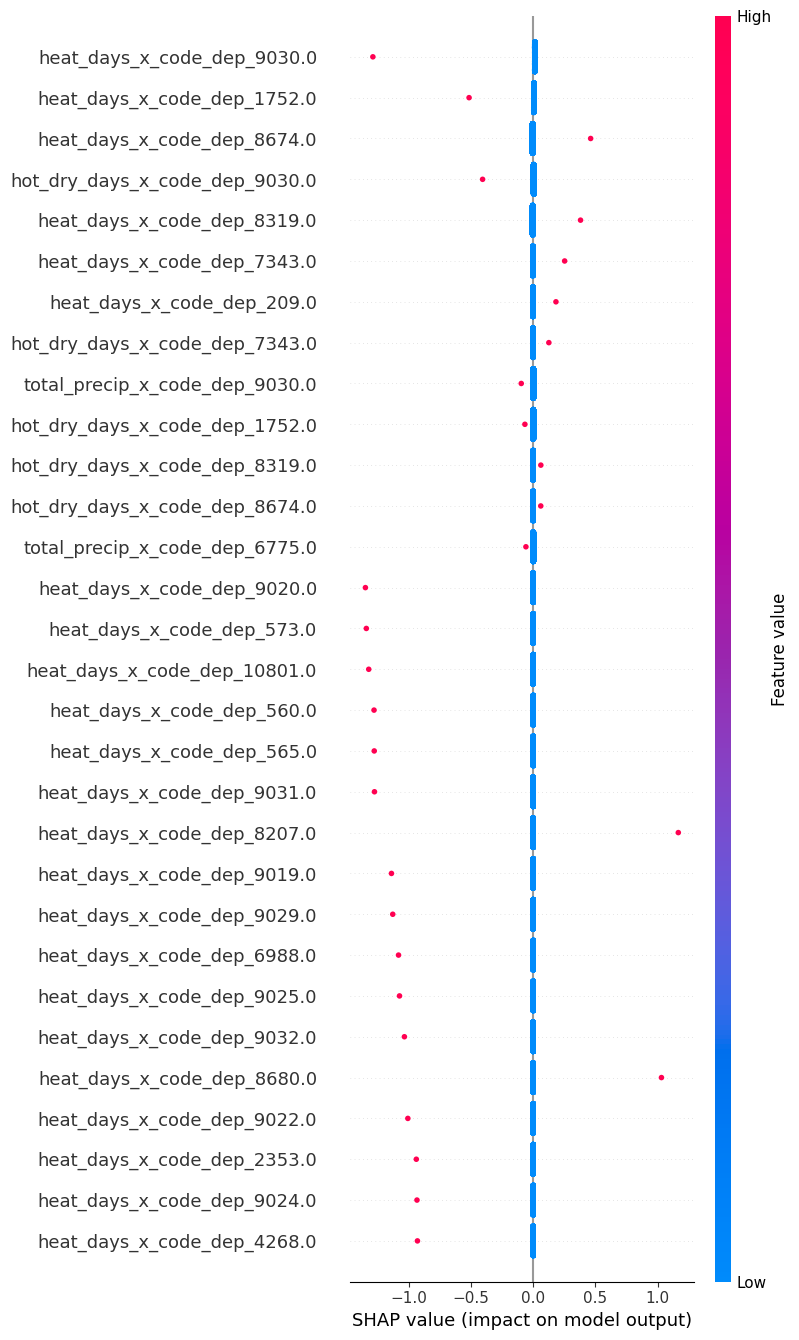

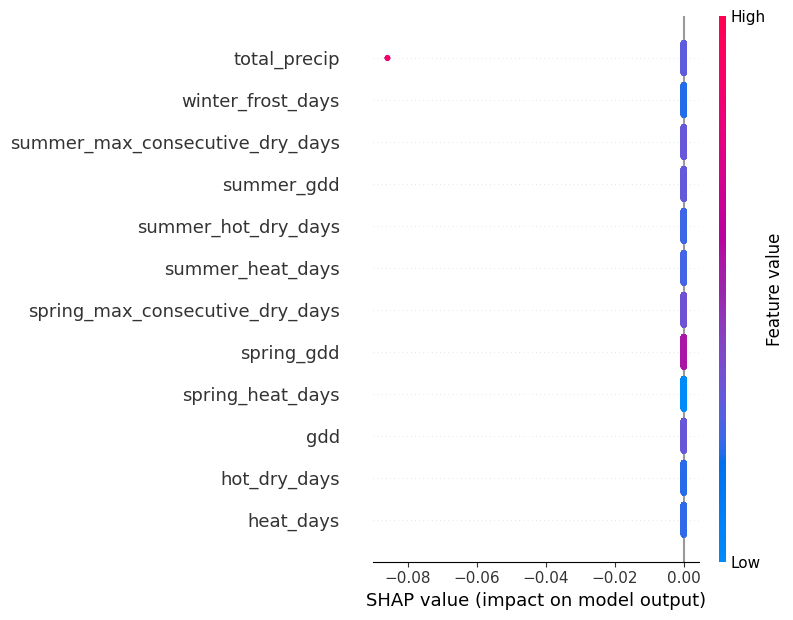

In [88]:
import shap

X_shap = X_num
CLIMATE_VARS = [
    "heat_days", "hot_dry_days", "total_precip", "gdd",
    "spring_heat_days", "spring_gdd", "spring_max_consecutive_dry_days",
    "summer_heat_days", "summer_hot_dry_days", "summer_gdd", "summer_max_consecutive_dry_days",
    "winter_frost_days"
]

# Keep only those that actually exist
CLIMATE_VARS = [c for c in CLIMATE_VARS if c in X.columns]
explainer = shap.Explainer(final_model, X_shap)
shap_values = explainer(X_shap)

# Global importance
shap.summary_plot(shap_values, X_shap, max_display=30)
shap.summary_plot(
    shap_values[:, [X.columns.get_loc(c) for c in CLIMATE_VARS]],
    X_shap[CLIMATE_VARS],
    max_display=20
)


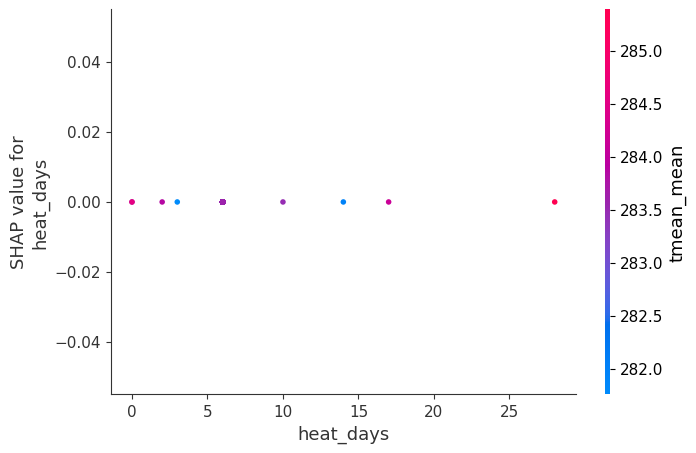

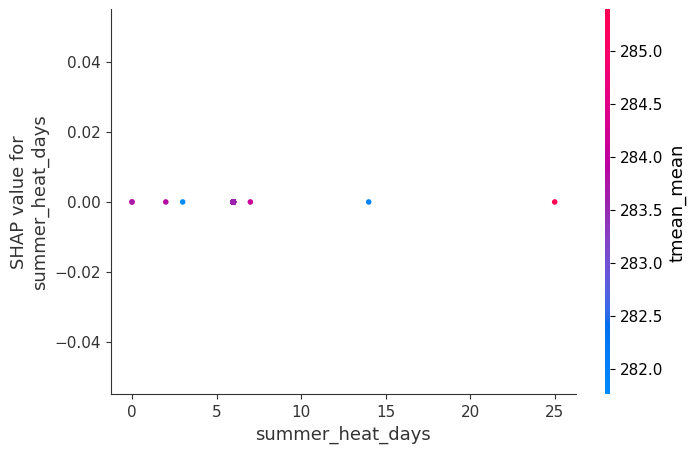

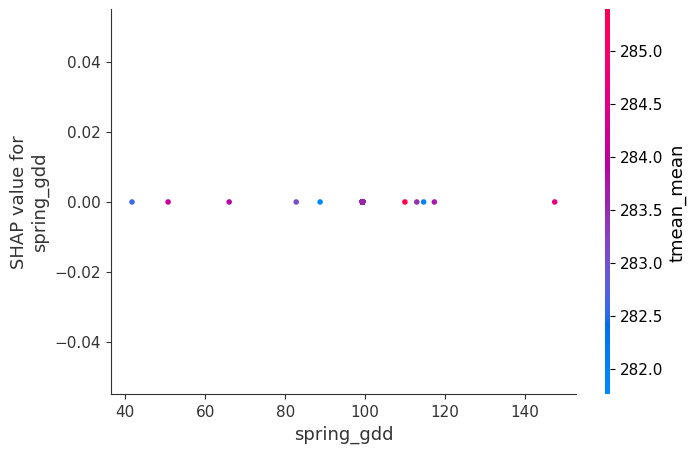

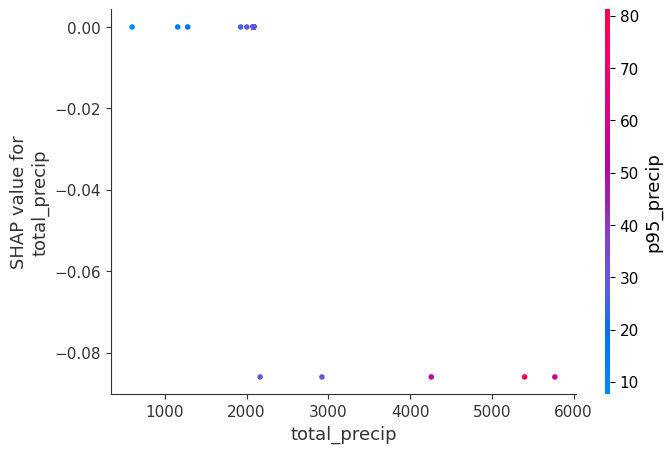

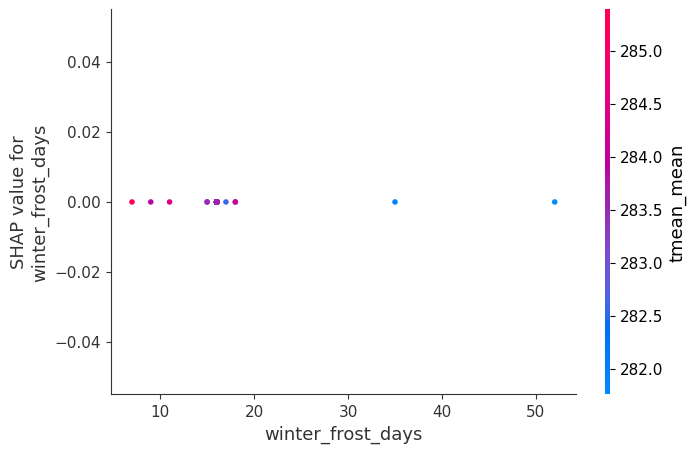

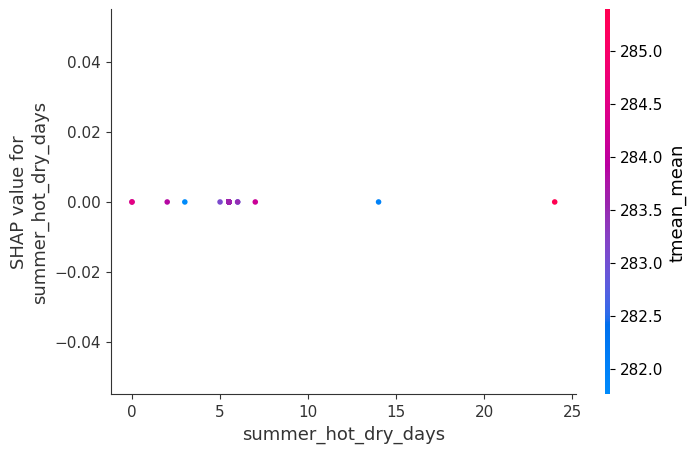

In [89]:
for v in ["heat_days", "summer_heat_days", "spring_gdd", "total_precip", "winter_frost_days","summer_hot_dry_days"]:
    if v in X.columns:
        shap.dependence_plot(v, shap_values.values, X_shap)
